## Logistic Regression on the Breast Cancer Dataset

In this example, we demonstrate how to:

Load the Breast Cancer dataset from sklearn

Explore and understand the data using pandas

Split the data into training and test sets

Train a custom LogisticRegression model from rice_ml

Evaluate the model using accuracy and loss

Visualize the learning curve (loss vs. iterations)

This notebook is meant to be a full workflow example:
data exploration → preprocessing → modeling → evaluation → visualization.

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc,
)

# Make sure we can import from src/
ROOT_DIR = Path.cwd().parents[2]        # .../CMOR438
SRC_PATH = ROOT_DIR / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from rice_ml.supervised_learning.logistic_regression import LogisticRegression


## 1. Load the Breast Cancer dataset

The Breast Cancer dataset is a widely used binary classification dataset in sklearn.
It contains:

569 samples (patients)

30 numeric features describing cell nuclei measurements

A binary target:

0 = malignant

1 = benign

We first load the dataset and inspect its basic structure.

In [10]:
# Load the Breast Cancer dataset (binary classification)
cancer = load_breast_cancer()

X = cancer.data          # shape: (n_samples, n_features)
y = cancer.target        # 0 = malignant, 1 = benign
feature_names = cancer.feature_names
target_names = cancer.target_names

print(f"Number of samples:  {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print("Classes:", target_names)




Number of samples:  569
Number of features: 30
Classes: ['malignant' 'benign']


## 2. Create a pandas DataFrame and inspect the data

For easier exploration, we convert the numpy arrays into a pandas DataFrame.
This allows us to:

Quickly view the first few rows

Compute summary statistics

Inspect correlations between features and the target variable

Check for potential class imbalance

This step helps us understand the dataset before training our model.

In [12]:
# Create a DataFrame for easier inspection
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
df["target_name"] = df["target"].map({0: "malignant", 1: "benign"})

df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


target_name
benign       357
malignant    212
Name: count, dtype: int64


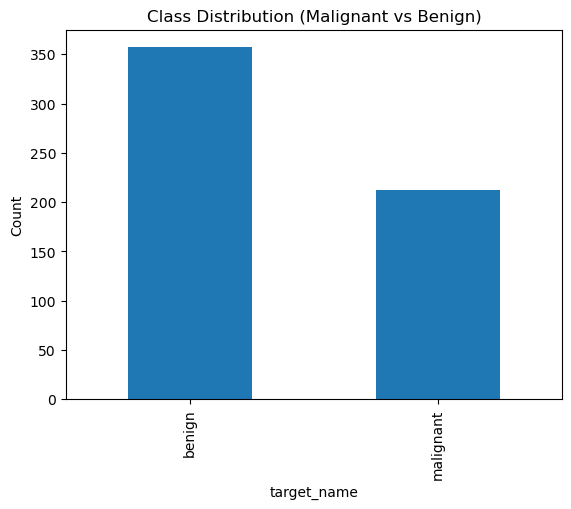

In [13]:
# Check class balance
class_counts = df["target_name"].value_counts()
print(class_counts)

class_counts.plot(kind="bar")
plt.ylabel("Count")
plt.title("Class Distribution (Malignant vs Benign)")
plt.show()

## 3. Split the data into training and testing sets

We divide the dataset into:

Training set: used to learn model parameters

Test set: used to evaluate generalization performance

A typical split is 80% training and 20% testing.
We also set a random seed for reproducibility.

In [14]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,   # keep class balance in each split
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape: ", X_test.shape, y_test.shape)

# Standardize features (important for gradient descent)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train shape: (455, 30) (455,)
Test shape:  (114, 30) (114,)


## 4. Train our custom Logistic Regression model

We use the LogisticRegression implementation from rice_ml.
This model:

Uses gradient descent to minimize logistic loss

Supports learning rate and number of iterations as hyperparameters

Returns both predictions and a loss history for visualization

After training the model, we inspect:

Final loss

Accuracy on the training set

Convergence behavior

In [15]:
# Initialize and fit our custom LogisticRegression model
log_reg = LogisticRegression(
    fit_intercept=True,
    learning_rate=0.1,
    max_iter=2000,
    tol=1e-6,
)

log_reg.fit(X_train_scaled, y_train)

print("Learned coefficients shape:", log_reg.coef_.shape)
print("Learned intercept:", log_reg.intercept_)


Learned coefficients shape: (30,)
Learned intercept: 0.37210865780249813


Number of iterations: 2000


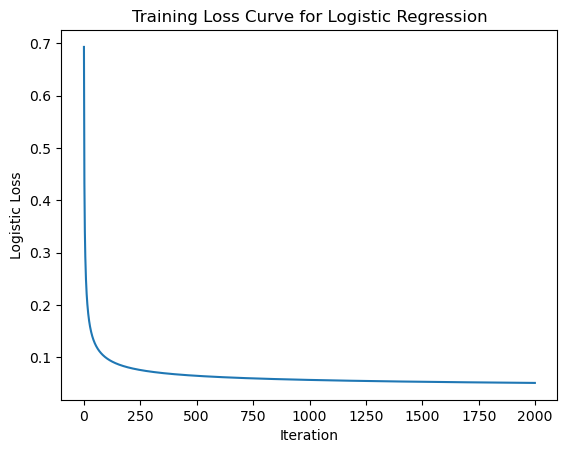

In [16]:
# Plot training loss over iterations
loss_history = log_reg.loss_history_
print(f"Number of iterations: {len(loss_history)}")

plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Logistic Loss")
plt.title("Training Loss Curve for Logistic Regression")
plt.show()


## 5. Evaluate the model on the test set

Once training is complete, we evaluate:

Prediction accuracy

Confusion matrix

Whether the model overfits or underfits

Accuracy gives us a general idea of performance,
while loss trends help diagnose optimization issues.

In [17]:
# Evaluate on train and test sets
train_acc = log_reg.accuracy(X_train_scaled, y_train)
test_acc = log_reg.accuracy(X_test_scaled, y_test)

train_loss = log_reg.log_loss(X_train_scaled, y_train)
test_loss = log_reg.log_loss(X_test_scaled, y_test)

print(f"Train accuracy: {train_acc:.3f}")
print(f"Test  accuracy: {test_acc:.3f}")
print(f"Train log loss: {train_loss:.3f}")
print(f"Test  log loss: {test_loss:.3f}")


Train accuracy: 0.989
Test  accuracy: 0.965
Train log loss: 0.051
Test  log loss: 0.079


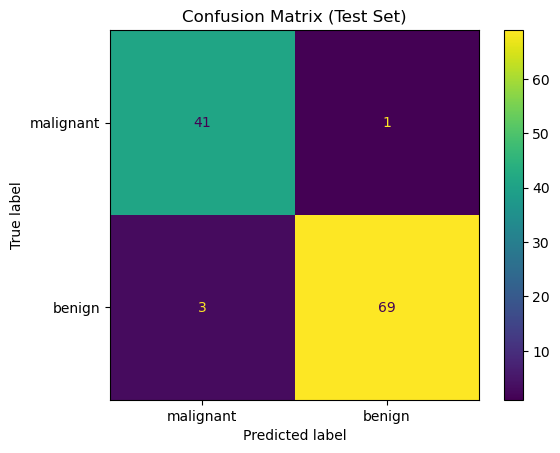

Classification report on test set:
              precision    recall  f1-score   support

   malignant       0.93      0.98      0.95        42
      benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



In [18]:
# Confusion matrix on the test set
y_test_pred = log_reg.predict(X_test_scaled, threshold=0.5)

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names,
)
disp.plot(values_format="d")
plt.title("Confusion Matrix (Test Set)")
plt.show()

# Classification report (precision, recall, f1)
print("Classification report on test set:")
print(classification_report(y_test, y_test_pred, target_names=target_names))


## 6. Visualize the learning curve

Finally, we plot:

Loss vs. number of iterations

This allows us to:

Verify whether gradient descent is converging

Detect learning-rate issues

Observe optimization stability

Visualization is an essential part of analyzing model performance.

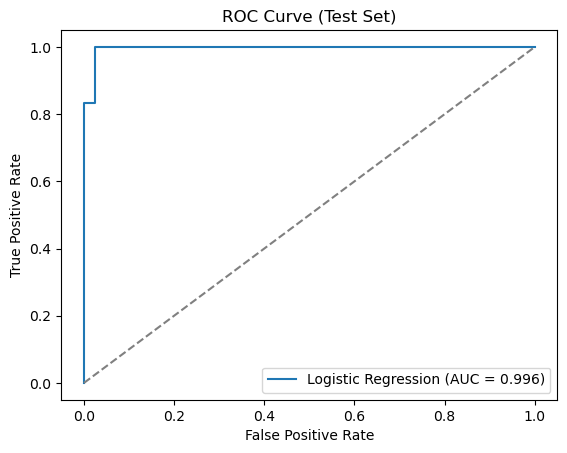

In [19]:
# ROC curve using predicted probabilities for class 1 (benign)
proba_test = log_reg.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, proba_test)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend()
plt.show()
